In [14]:
#%pip install tqdm
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.Collecting ipywidgets
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 6.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------- ----------- 1.6/2.2 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.5 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [i


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
# Import models you're considering
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import ResNet50_Weights, resnet50, ResNet18_Weights, resnet18
from tqdm.notebook import tqdm #for a progress bar

In [3]:
# check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


In [4]:
class ARPESDataset(Dataset):

    def __init__(self, h5_path, labels, indices, transform=None):

        self.h5_path = h5_path
        self.labels = np.array(labels)
        self.indices = np.array(indices)
        self.transform = transform

        self._file = None
        self._data = None

    def _init_file(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
            self._data = self._file["entry/acquisition/data"]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):

        self._init_file()

        idx = self.indices[i]
        img = self._data[:, :, idx]

        if self.transform:
            img = self.transform(img)

        if not torch.is_tensor(img):
            img = torch.tensor(img, dtype=torch.float32)

        if img.ndim == 2:
            img = img.unsqueeze(0)
        elif img.ndim == 3 and img.shape[0] != 1:
            # already channel-first tensor
            pass

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return img, label

In [18]:
class LogNormalize:
    def __call__(self, img):
        img = np.log1p(img.astype(np.float32))
        img = img - img.min()
        img = img / (img.max() + 1e-8)
        return img

In [19]:
transform = transforms.Compose([
    #RandomEnergyWindowCrop(4.9, 6.8, window_width_eV=1.2),
    LogNormalize(),
    transforms.ToTensor(),
    #transforms.Resize((288, 216))
])

In [20]:

#labels_path = '/Users/atimm/Documents/ML/data/Classification_table.csv'
labels_path = '../../../ML_data/Classification_table.csv'
labels_df = pd.read_csv(labels_path, delimiter=';', usecols=['Symmetrie', 'Resolution'])

y = labels_df['Symmetrie'] * labels_df['Resolution']

#h5_path = '/Volumes/SHARES/AG-PES/RW_EXCHANGE/TeamMembers/!MachineLearning/x_y_grid_20260417_105734_020_raw/x_y_grid_20260417_105734_020_z000000_snapshot/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5'
h5_path ='../../../ML_data/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5'

with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
    data = f["entry/acquisition/data"]
    num_samples = data.shape[2]
    print(data.chunks)

(288, 216, 67)


In [7]:
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=42
)


train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.1765,  # 0.1765 * 0.85 ≈ 0.15 of total data
    random_state=42
)

In [22]:
train_dataset = ARPESDataset(h5_path, y, train_idx, transform)
val_dataset   = ARPESDataset(h5_path, y, val_idx, transform)
test_dataset  = ARPESDataset(h5_path, y, test_idx, transform)

#verify the splits
print(f"Train set size: {len(train_dataset)}")  
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Train set size: 1235
Validation set size: 265
Test set size: 265


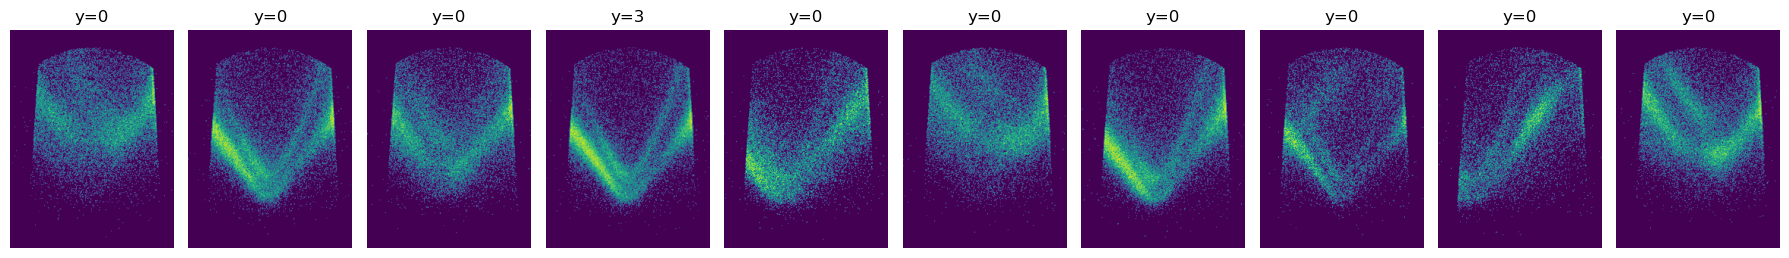

In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

fig, ax = plt.subplots(1, 10, figsize=(18, 3))
for i in range(10):
     img, label = train_dataset[i]
     ax[i].set_title(f"y={label.item()}")
     ax[i].axis("off")
     ax[i].imshow(img.squeeze(0))
plt.tight_layout()
plt.show()

In [24]:
model = resnet18(pretrained=True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(np.unique(y)))

# Transfer learning: freeze all parameters except final fc
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)


c:\Users\torbe\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\torbe\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
# Optimizer: only params with requires_grad=True
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()



In [27]:
num_epochs = 10
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        correct = 0
        total = 0

        #for inputs, labels in tqdm(dataloader, desc=f"{phase.capitalize()} epoch {epoch+1}"):
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

Epoch 1/10
Train Loss: 1.5502 Acc: 0.2988
Val Loss: 1.5396 Acc: 0.3774
Epoch 2/10


KeyboardInterrupt: 